In [ ]:
from pathlib import Path
import os

if "__vsc_ipynb_file__" in globals():
    os.chdir(Path(__vsc_ipynb_file__).resolve().parent)

print(f"cwd: {Path.cwd()}")

cwd: /project/chihway/junzhou/Project-Roman-Y1/plots/compare_desy3


In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
from utils import load_chain_parameters
import getdist
from getdist import loadMCSamples, plots, mcsamples
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

#needed for plots
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from getdist import plots

In [9]:
def DES_LOAD(filepath, settings):

    required_parameters = ["omegam", "sigma8"]

    parameters_y3, weights_y3 = load_chain_parameters(
        filepath,
        required_parameters,
    )


    sample = mcsamples.MCSamples(
            samples=np.array(parameters_y3), 
            weights=np.array(weights_y3), 
            names=['omegam', 'sigma8' ], 
            labels=['$\\Omega_m$','$\\Sigma_8$'],
            settings=settings)

    return sample

def load(filepath, settings={'ignore_rows':0.2, 'contours': [0.68]}):
    try:
        sample = loadMCSamples(filepath, settings=settings)
    except:
        print(f"Usual loading failed for {filepath}")
        try:
            sample = DES_LOAD(filepath, settings)
        except:
            print(f"DES loading failed for {filepath}")
            print(f"Check your filepath or files")
            return None

    p = sample.getParams()
    s8 = p.sigma8*(p.omegam/0.3)**0.5
    try:
        sample.addDerived(
            s8,
            'S8',
            label = r'S_8'
        )
    except:
        print(f"Error adding derived parameter for {filepath}")
    means = sample.getMeans()
    ix = sample.getParamNames().numberOfName('omegam')
    iy = sample.getParamNames().numberOfName('S8')
    delta_s8     = s8 - means[iy]
    delta_omegam = p.omegam - means[ix]
    try:
        sample.addDerived(
            delta_s8,
            'delta_S8',
            label = r'\Delta S_8'
        )
        sample.addDerived(
            delta_omegam,
            'delta_omegam',
            label = r'\Delta \Omega_m'
        )
    except:
        True
    return sample  

def plot_compare(samples, labels, params, print_stats=False, params_stats:list[str] = None, savepath=None):


    g = plots.get_subplot_plotter(subplot_size=columnwidth, width_inch=columnwidth*1.1, subplot_size_ratio = 1, )
    g.make_figure(nplot=1, nx=1)
    g.settings.tight_layout = False
    g.settings.title_limit = 1
    g.settings.title_limit_labels = True
    g.settings.title_limit_fontsize = 10
    g.settings.lab_fontsize = 10
    g.settings.legend_fontsize = 10
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 10
    g.settings.axes_labelsize = 10
    g.settings.axis_tick_max_labels = 4
    g.settings.alpha_factor_contour_lines = 3.0

    #params = ['delta_omegam', 'delta_S8']
    #labels = ['Roman_Y1_41', 'Roman_Y1_60', 'DES_Y3', 'DES_Y1']

    nsample = len(labels)

    g.plot_2d(
        roots = samples[:nsample], 
        param_pair=params, 
        legend_labels= labels,
        colors=['#FFAF4C', '#9A6289', '#7386BE', '#959596', '#4C9987'],
        ls = ['-','-.',':','--','--'],
        lws = [2.5, 2.5, 2.5, 2.5, 2.5],
        alphas = [0.3, 0.3, 0.3, 0.3, 0.3],
        filled = [True, True, True, True, True],
        lims = [-0.2, 0.2, -0.2, 0.2],
        ax=(0,0)
    )

    ax = g.get_axes(ax=(0,0))
    from matplotlib.ticker import MultipleLocator, AutoMinorLocator
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(MultipleLocator(0.025))
    ax.xaxis.set_major_locator(MultipleLocator(0.06))
    ax.xaxis.set_minor_locator(MultipleLocator(0.03))
    ax.text(x = 0.6, y = 0.1, s = r'$\Lambda$CDM - ShearOnly', transform=ax.transAxes)

#--------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------
    colors = ['#FFAF4C', '#9A6289', '#7386BE', '#959596', '#4C9987']
    linestyles = ['-', '-.', ':', (0, (3,1,1,1,1,1)), (0, (5, 1, 2, 1, 3, 1))]
    alphas = [0.8, 0.8, 0.8, 0.8, 0.8]
    filled_flags = [True, True, True, True, True]

    dataset_handles = []
    for lab, c, ls, a, is_filled in zip(labels[:nsample], colors[:nsample], linestyles[:nsample], alphas[:nsample], filled_flags[:nsample]):
        if is_filled:
            h = Patch(facecolor=c, edgecolor=c, linestyle=ls, linewidth=2.0, alpha=a, label=lab)
        else:
            h = Line2D([0], [0], color=c, linestyle=ls, linewidth=1.25, alpha=a, label=lab)
        dataset_handles.append(h)

    g.legend = g.fig.legend(
        dataset_handles,
        labels,
        loc='lower center',
        bbox_to_anchor=(0.55, 0.90),
        ncol=3,
        frameon=False,
        fontsize=10
    )

    if print_stats:
        if params_stats is None:
            params_stats = ['omegam', 'S8']
        nparam = len(params_stats)

        for isample, sample in enumerate(samples):
            for i in range(nparam):
                p = params_stats[i]
                stat = sample.getMargeStats().parWithName(p)
                mean = stat.mean
                upper_bound = stat.limits[0].upper
                lower_bound = stat.limits[0].lower
                print(f'{labels[isample]} {p} = {mean:.3f} + {upper_bound - mean:.3f} - {mean - lower_bound:.3f}')

    g.extra_artists = [g.legend]
    if savepath is not None:
        g.export(savepath, dpi=300)

def compare_chains_single(
    filepaths: list[str],
    labels: list[str],
    params: list[str],
    print_stats: bool = False,
    params_stats: list[str] = None,
    savepath: str = None
):
    # Sanity checks
    if len(filepaths) != len(labels):
        raise ValueError("filepaths and labels must have the same length")

    # Load chains
    samples = []
    for i in range(len(filepaths)):
        samples.append(load(filepaths[i]))
        if samples[-1] is None:
            raise RuntimeError(f"Failed to load chain: {filepaths[i]}")
        # clear wrong latex
        pn = samples[-1].getParamNames()
        for p in pn.names:
            if p.name == 'mnu':
                p.label = r'm_{\nu}'
            if p.name.lower() == 'omegan':
                p.label = r'\Omega_{\nu}'
            if p.name == 'As_1e9':
                p.label = r'10^{9} A_{\rm s}'

    plot_compare(samples,labels, params, print_stats=print_stats, params_stats=params_stats, savepath=savepath)

    return samples


Usual loading failed for ./chains/s_l3.txt
Removed 0.2 as burn in
Usual loading failed for ./chains/chain_1x2pt_lcdm_SR_maglim.txt
Removed 0.2 as burn in


ROMAN_Y1_41 omegam = 0.298 + 0.047 - 0.088
ROMAN_Y1_41 S8 = 0.814 + 0.046 - 0.039


ROMAN_Y1_60 omegam = 0.297 + 0.043 - 0.084
ROMAN_Y1_60 S8 = 0.820 + 0.034 - 0.030
DES_Y1 omegam = 0.290 + 0.040 - 0.064
DES_Y1 S8 = 0.778 + 0.030 - 0.023
DES_Y3 omegam = 0.290 + 0.041 - 0.060
DES_Y3 S8 = 0.759 + 0.023 - 0.023


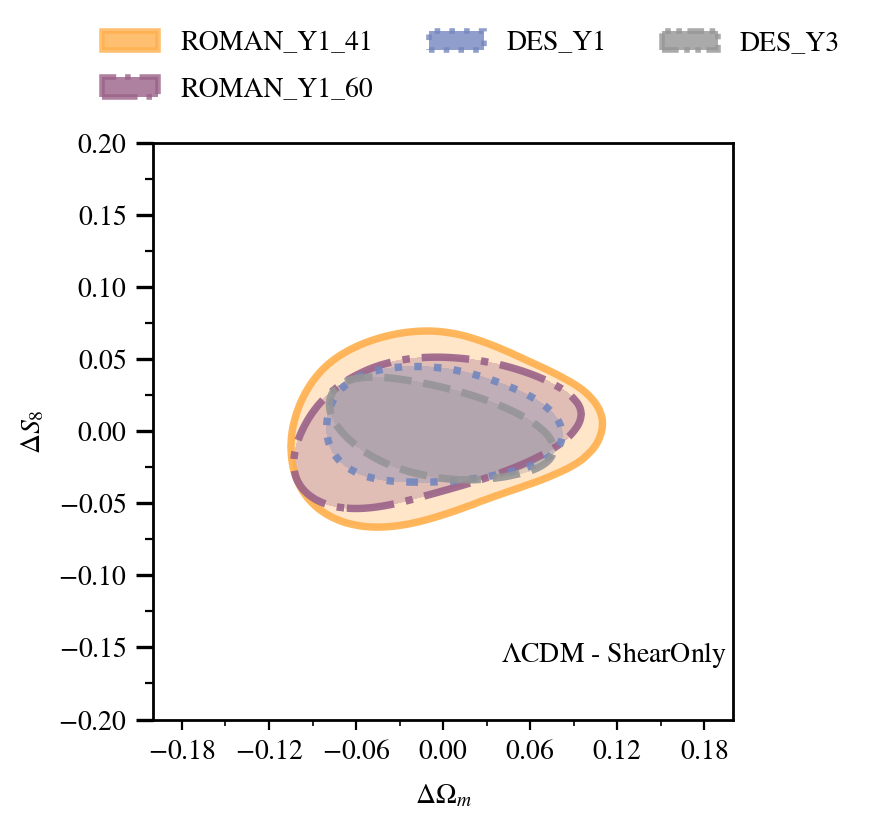

In [11]:
samples = compare_chains_single(
    filepaths=['./chains/roman_lsst_41_mcmc/', './chains/roman_lsst_60_mcmc/', './chains/s_l3.txt', './chains/chain_1x2pt_lcdm_SR_maglim.txt'],
    labels=['ROMAN_Y1_41', 'ROMAN_Y1_60', 'DES_Y1', 'DES_Y3'],
    params=['delta_omegam', 'delta_S8'],
    print_stats=True,
    params_stats=['omegam', 'S8'],
    savepath='RomanY1_vs_DES.jpg'
)

Usual loading failed for ./chains/s_l3.txt
Removed 0.2 as burn in


DES_Y1_COCOA omegam = 0.272 + 0.042 - 0.064
DES_Y1_COCOA S8 = 0.789 + 0.029 - 0.028
DES_Y1 omegam = 0.290 + 0.040 - 0.064
DES_Y1 S8 = 0.778 + 0.030 - 0.023
140528
3826


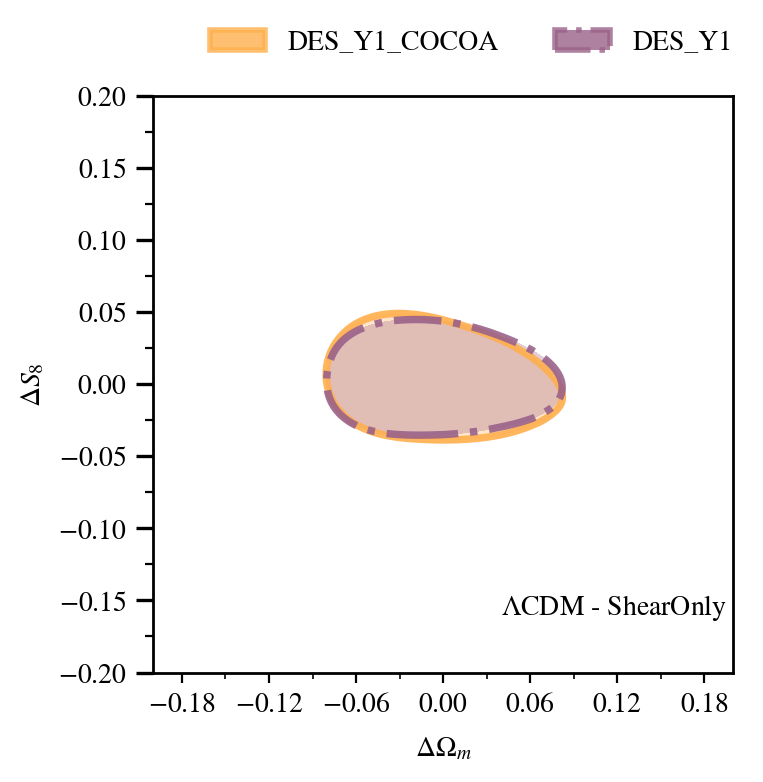

In [12]:
samples = compare_chains_single(
    filepaths=['./chains/des_y1_mcmc/', './chains/s_l3.txt'],
    labels=['DES_Y1_COCOA', 'DES_Y1'],
    params=['delta_omegam', 'delta_S8'],
    print_stats=True,
    params_stats=['omegam', 'S8'],
    savepath='COCOA_4_DES_Y1.jpg'
)
for sample in samples:
    print(len(sample.weights))

Usual loading failed for ./chains/chain_1x2pt_lcdm_SR_maglim.txt
Removed 0.2 as burn in


DES_Y3_COCOA omegam = 0.280 + 0.042 - 0.052
DES_Y3_COCOA S8 = 0.777 + 0.032 - 0.026
DES_Y3 omegam = 0.290 + 0.041 - 0.060
DES_Y3 S8 = 0.759 + 0.023 - 0.023
291063
7850


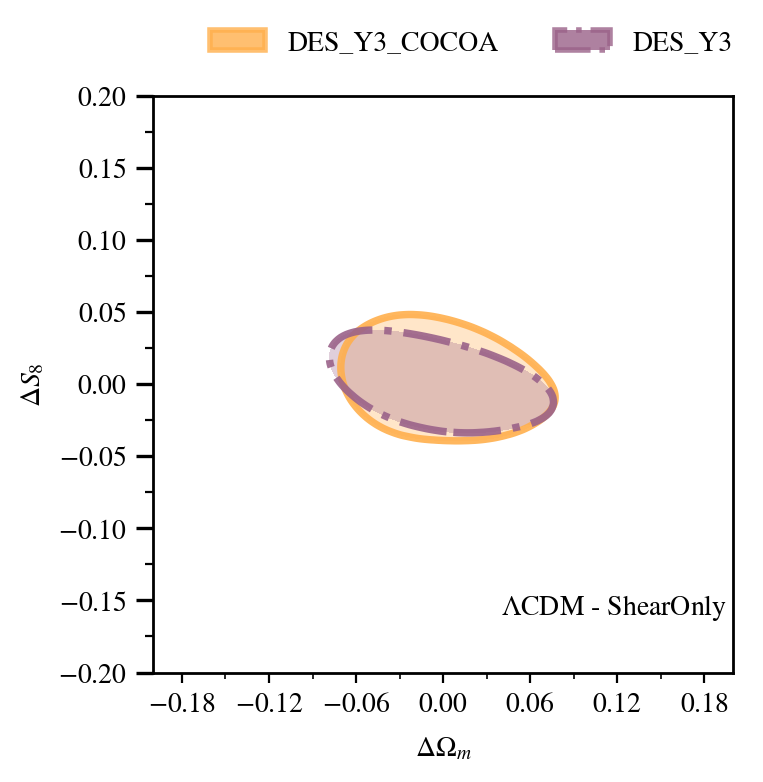

In [14]:
samples = compare_chains_single(
    filepaths=['./chains/des_y3_mcmc/', './chains/chain_1x2pt_lcdm_SR_maglim.txt'],
    labels=['DES_Y3_COCOA', 'DES_Y3'],
    params=['delta_omegam', 'delta_S8'],
    print_stats=True,
    params_stats=['omegam', 'S8'],
    savepath='COCOA_4_DES_Y3.jpg'
)
for sample in samples:
    print(len(sample.weights))